   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 38.4 MB/s eta 0:00:00
✅ Environment is fully configured and core data environments generated!


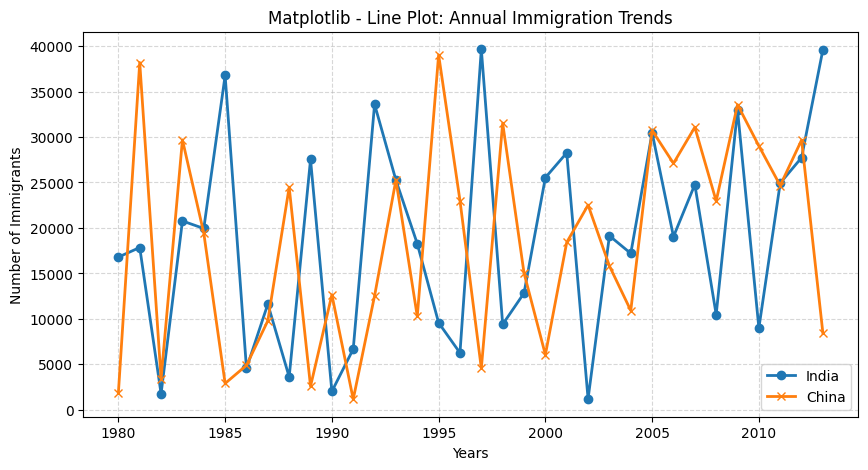

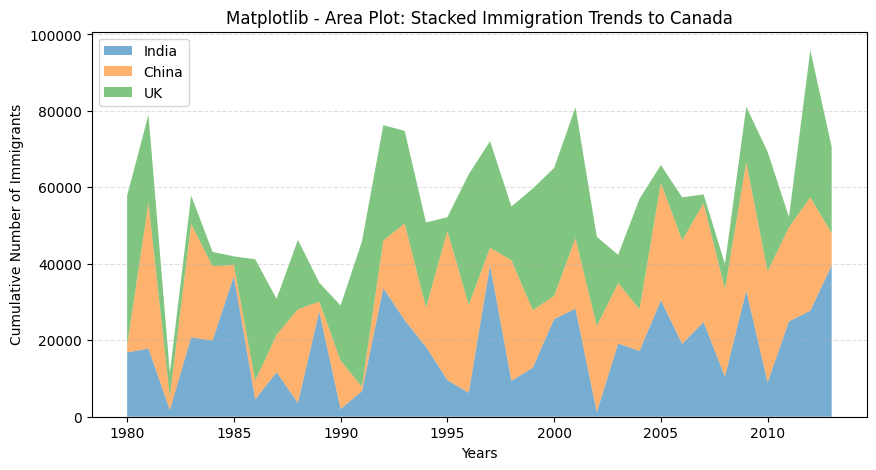

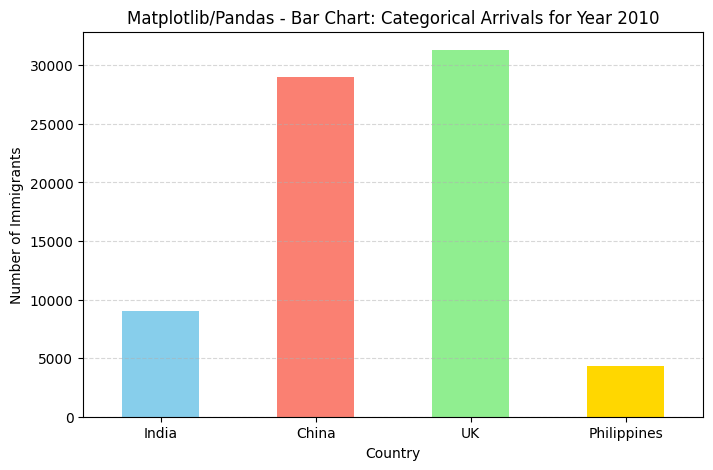

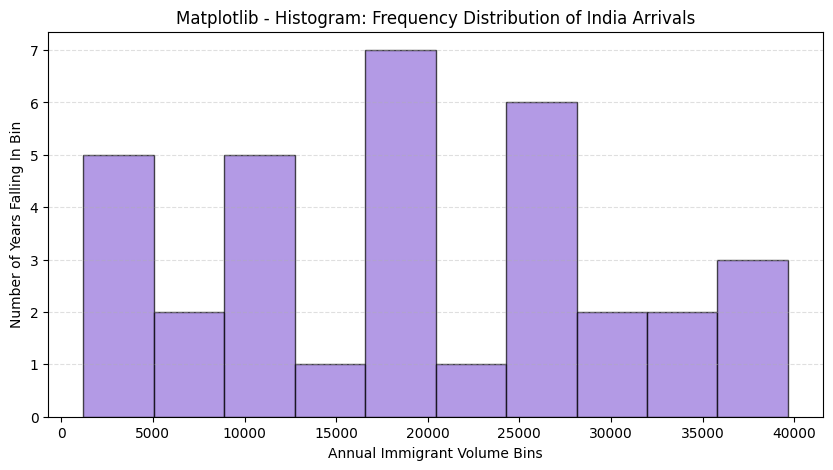

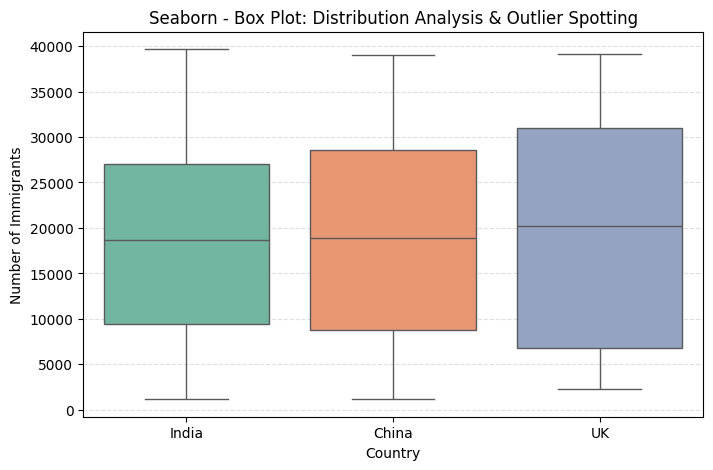

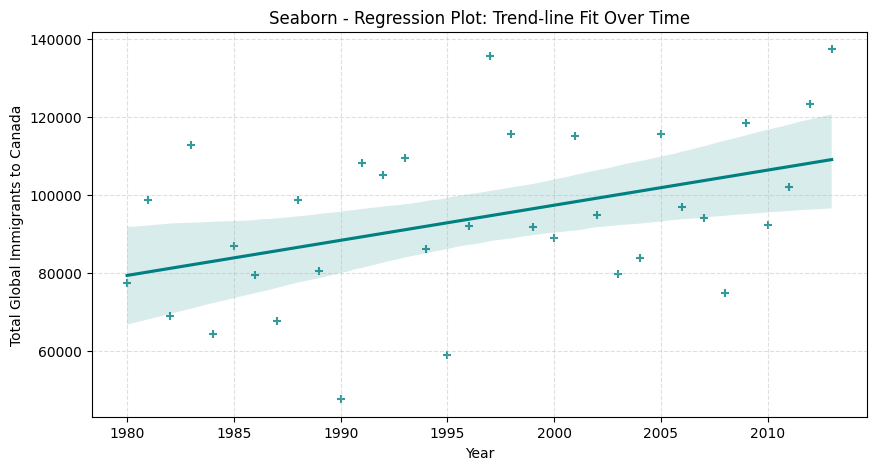

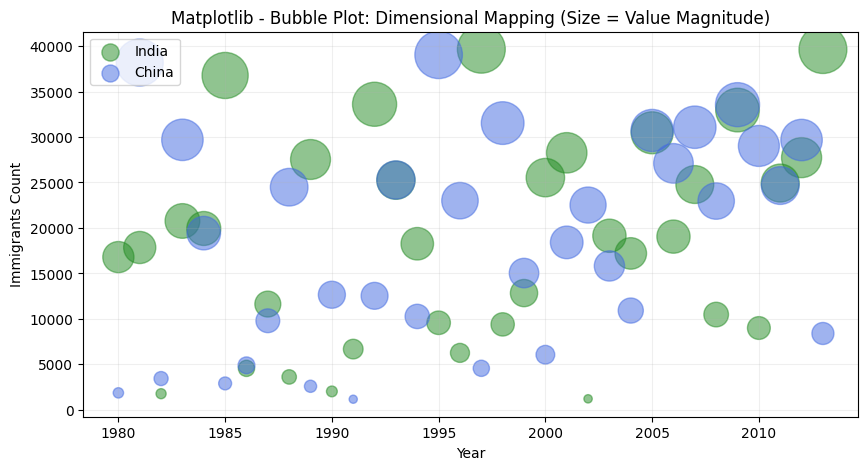

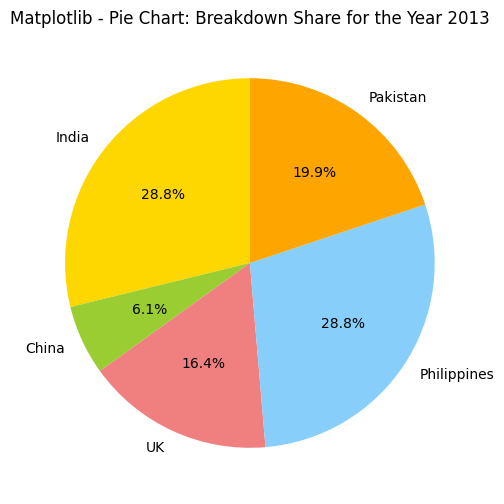

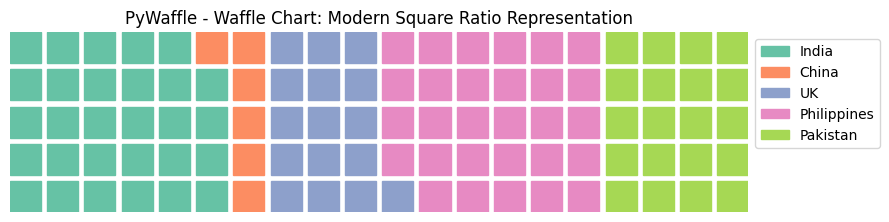

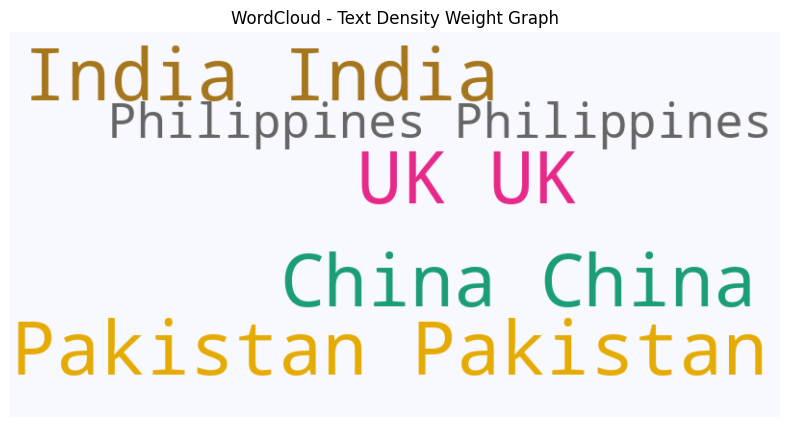


--- Displaying Interactive Folium Map Object ---


In [1]:
!pip install pandas matplotlib seaborn plotly dash folium wordcloud pywaffle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from wordcloud import WordCloud
from pywaffle import Waffle

# Seed generation for data repeatability
np.random.seed(42)
years = list(map(str, range(1980, 2014)))

# Dataset A: Simulation of the famous "Immigration to Canada" dataset
countries = ['India', 'China', 'UK', 'Philippines', 'Pakistan']
data_imm = {yr: np.random.randint(1000, 40000, size=len(countries)) for yr in years}
data_imm['Country'] = countries
df_canada = pd.DataFrame(data_imm).set_index('Country')
df_canada['Total'] = df_canada[years].sum(axis=1)
df_top3 = df_canada.loc[['India', 'China', 'UK'], years].T

# Dataset B: Simulation of Flight Performance Data (used in dashboard modules)
df_flights = pd.DataFrame({
    'Reporting_Airline': np.random.choice(['AA', 'UA', 'DL', 'WN'], size=500),
    'ArrDelay': np.random.normal(loc=15, scale=30, size=500),
    'DepDelay': np.random.normal(loc=12, scale=25, size=500),
    'Distance': np.random.randint(100, 2500, size=500),
    'Month': np.random.randint(1, 13, size=500)
})

print("✅ Environment is fully configured and core data environments generated!")

# ------------------------------------------------------------------------------
# # matplotlib
# # Type of Plot: Line Plot
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(df_top3.index, df_top3['India'], label='India', marker='o', linewidth=2)
plt.plot(df_top3.index, df_top3['China'], label='China', marker='x', linewidth=2)
plt.title('Matplotlib - Line Plot: Annual Immigration Trends', fontsize=12)
plt.xlabel('Years')
plt.ylabel('Number of Immigrants')
plt.xticks(df_top3.index[::5])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# # matplotlib
# # Type of Plot: Area Plot / Stacked Area Chart
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.stackplot(df_top3.index, df_top3['India'], df_top3['China'], df_top3['UK'],
              labels=['India', 'China', 'UK'], alpha=0.6)
plt.title('Matplotlib - Area Plot: Stacked Immigration Trends to Canada', fontsize=12)
plt.xlabel('Years')
plt.ylabel('Cumulative Number of Immigrants')
plt.xticks(df_top3.index[::5])
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# ------------------------------------------------------------------------------
# # matplotlib / pandas
# # Type of Plot: Bar Chart (Vertical)
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
df_canada.loc[['India', 'China', 'UK', 'Philippines'], '2010'].plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'gold'])
plt.title('Matplotlib/Pandas - Bar Chart: Categorical Arrivals for Year 2010', fontsize=12)
plt.xlabel('Country')
plt.ylabel('Number of Immigrants')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# ------------------------------------------------------------------------------
# # matplotlib
# # Type of Plot: Histogram
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(df_canada.loc['India', years], bins=10, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Matplotlib - Histogram: Frequency Distribution of India Arrivals', fontsize=12)
plt.xlabel('Annual Immigrant Volume Bins')
plt.ylabel('Number of Years Falling In Bin')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# ------------------------------------------------------------------------------
# # seaborn
# # Type of Plot: Box Plot
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_top3[['India', 'China', 'UK']], palette="Set2")
plt.title('Seaborn - Box Plot: Distribution Analysis & Outlier Spotting', fontsize=12)
plt.xlabel('Country')
plt.ylabel('Number of Immigrants')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# ------------------------------------------------------------------------------
# # seaborn
# # Type of Plot: Scatter Plot with Regression Line (regplot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
years_int = list(map(int, years))
df_total_years = pd.DataFrame({'Year': years_int, 'Total': df_canada[years].sum(axis=0).values})
sns.regplot(x='Year', y='Total', data=df_total_years, color='teal', marker='+')
plt.title('Seaborn - Regression Plot: Trend-line Fit Over Time', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Total Global Immigrants to Canada')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ------------------------------------------------------------------------------
# # matplotlib
# # Type of Plot: Bubble Plot
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
size_india = df_canada.loc['India', years] * 0.03
size_china = df_canada.loc['China', years] * 0.03
plt.scatter(years_int, df_canada.loc['India', years], s=size_india, alpha=0.5, color='forestgreen', label='India')
plt.scatter(years_int, df_canada.loc['China', years], s=size_china, alpha=0.5, color='royalblue', label='China')
plt.title('Matplotlib - Bubble Plot: Dimensional Mapping (Size = Value Magnitude)', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Immigrants Count')
plt.legend(loc='upper left', markerscale=0.5)
plt.grid(True, alpha=0.2)
plt.show()

# ------------------------------------------------------------------------------
# # matplotlib
# # Type of Plot: Pie Chart
# ------------------------------------------------------------------------------
plt.figure(figsize=(6, 6))
df_pie_data = df_canada['2013']
plt.pie(df_pie_data, labels=df_pie_data.index, autopct='%1.1f%%', startangle=90,
        colors=['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'orange'])
plt.title('Matplotlib - Pie Chart: Breakdown Share for the Year 2013', fontsize=12)
plt.show()

# ------------------------------------------------------------------------------
# # pywaffle
# # Type of Plot: Waffle Chart
# ------------------------------------------------------------------------------
data_waffle = df_canada['2013'].to_dict()
total_waffle = sum(data_waffle.values())
proportions = {k: int(v / total_waffle * 100) for k, v in data_waffle.items()}

fig_waffle = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=proportions,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(9, 3)
)
plt.title('PyWaffle - Waffle Chart: Modern Square Ratio Representation', fontsize=12)
plt.show()

# ------------------------------------------------------------------------------
# # wordcloud
# # Type of Plot: Word Cloud
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
text_data = " ".join([country.replace(' ', '_') for country in df_canada.index for _ in range(int(df_canada.loc[country, 'Total'] // 20000))])
wordcloud = WordCloud(width=800, height=400, background_color='ghostwhite', colormap='Dark2').generate(text_data)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Text Density Weight Graph', fontsize=12)
plt.show()

# ------------------------------------------------------------------------------
# # plotly.express
# # Type of Plot: Interactive Scatter Plot
# ------------------------------------------------------------------------------
fig_plotly_scatter = px.scatter(df_flights, x="DepDelay", y="ArrDelay", color="Reporting_Airline",
                                 size="Distance", hover_data=['Month'],
                                 title="Plotly Express - Interactive Scatter Plot (Click Legend / Zoom / Hover)")
fig_plotly_scatter.show()

# ------------------------------------------------------------------------------
# # plotly.express
# # Type of Plot: Interactive Pie Chart
# ------------------------------------------------------------------------------
df_pie_flights = df_flights.groupby('Reporting_Airline')['Distance'].sum().reset_index()
fig_plotly_pie = px.pie(df_pie_flights, values='Distance', names='Reporting_Airline',
                         title='Plotly Express - Interactive Flight Distance Proportions Pie')
fig_plotly_pie.show()

# ------------------------------------------------------------------------------
# # plotly.express
# # Type of Plot: Sunburst Chart
# ------------------------------------------------------------------------------
fig_plotly_sunburst = px.sunburst(df_flights, path=['Reporting_Airline', 'Month'], values='Distance',
                                   title="Plotly Express - Sunburst Chart: Hierarchical Multi-Level Proportions")
fig_plotly_sunburst.show()

# ------------------------------------------------------------------------------
# # folium
# # Type of Plot: Interactive Geospatial Map
# ------------------------------------------------------------------------------
# Creates an active map frame focused over the country of Canada
interactive_map = folium.Map(location=[56.130, -106.35], zoom_start=4)

# Create map overlay group container
marker_layer = folium.map.FeatureGroup()

# Attach a localized vector element circle marker at Ottawa coordinates
marker_layer.add_child(
    folium.features.CircleMarker(
        [45.4215, -75.6972],
        radius=12,
        color='blue',
        fill=True,
        fill_color='cyan',
        fill_opacity=0.4
    )
)

# Place an interactively clickable pin descriptor anchor
folium.Marker([45.4215, -75.6972], popup='<b>Ottawa Central Hub Marker</b>').add_to(interactive_map)
interactive_map.add_child(marker_layer)

print("\n--- Displaying Interactive Folium Map Object ---")
interactive_map